
# Chapter 13 Companion Python Notebook: Free Shear Flow 

Book: Principles of Turbulence: An introduction with Python Examples
Author: Kiran Bhaganagar

This notebook accompanies the worked examples for canonical free shear flows:

1. turbulent plane mixing-layer growth,
2. turbulent round-jet centerline decay and spreading,
3. pure turbulent plume centerline scaling,
4. turbulent kinetic-energy production in mixing layers, jets, and plumes,
5. entrainment and volume-flux growth in a round jet.

The purpose is not to solve the full Reynolds-averaged equations, but to connect the similarity scalings and integral constraints to simple calculations and visual diagnostics.




### Table of Contents

1. Introduction and Learning Objectives

2. Governing Equations for Free Shear Flows

3. Loading Required Libraries

4. Turbulent Plane Mixing Layer
   - 4.1 Synthetic Mixing-Layer Velocity Field
   - 4.2 Similarity Coordinate
   - 4.3 Vorticity Thickness
   - 4.4 Reynolds Shear Stress
   - 4.5 Turbulent Kinetic-Energy Production
   - 4.6 Growth of Mixing-Layer Thickness
   - 4.7 Self-Similar Mean Velocity Profiles

5. Axisymmetric Turbulent Jet
   - 5.1 Synthetic Jet Velocity Field
   - 5.2 Centerline Velocity Decay
   - 5.3 Jet Spreading Rate
   - 5.4 Volume Flux
   - 5.5 Momentum Flux Conservation
   - 5.6 Entrainment Velocity
   - 5.7 Self-Similar Jet Profiles

6. Buoyant Plume
   - 6.1 Synthetic Plume Velocity Field
   - 6.2 Synthetic Buoyancy Field
   - 6.3 Buoyancy Flux Conservation
   - 6.4 Plume Width Growth
   - 6.5 Centerline Velocity Scaling
   - 6.6 Self-Similar Velocity and Buoyancy Profiles

7. Entrainment in Free Shear Flows
   - 7.1 Volume Flux Growth
   - 7.2 Entrainment Coefficient
   - 7.3 Linear Growth of Characteristic Width

8. Worked Examples
   - Example 13.1: Growth of a Turbulent Mixing Layer
   - Example 13.2: Turbulent Round Jet
   - Example 13.3: Pure Turbulent Plume
   - Example 13.4: TKE Production
   - Example 13.5: Jet Entrainment

9. Synthetic Flow Problems
   - Problem 1: Turbulent Mixing Layer
   - Problem 2: Axisymmetric Jet
   - Problem 3: Buoyant Plume
   - Problem 4: Unified Flow Comparison
   - Problem 5: Sensitivity to Entrainment Coefficient

10. Unified Comparison of Canonical Free Shear Flows
    - Mixing Layer vs Jet vs Plume
    - Growth Rates
    - Similarity Profiles
    - Velocity Scaling
    - Conserved Quantities
    - Entrainment

11. Summary and Key Physical Insights

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# Use readable default plot settings without imposing a custom color style.
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 2.2,
})



## Example 13.1: Growth of a turbulent plane mixing layer

For a plane mixing layer with upper and lower stream velocities \(U_1\) and \(U_2\), the velocity difference is

\[
\Delta U = U_1-U_2.
\]

Using the linear growth law for the vorticity thickness,

\[
\delta_\omega(x)=K_\omega x,
\]

the maximum mean velocity gradient follows from

\[
\delta_\omega = \frac{\Delta U}{\left(\partial U/\partial y\right)_{\max}}.
\]


In [2]:

# Given values
U1 = 20.0       # m/s
U2 = 5.0        # m/s
K_omega = 0.10  # growth coefficient
x_eval = 0.40   # m

DeltaU = U1 - U2
U_conv = 0.5 * (U1 + U2)
delta_omega = K_omega * x_eval
dUdy_max = DeltaU / delta_omega

print(f"Delta U = {DeltaU:.2f} m/s")
print(f"Convective velocity = {U_conv:.2f} m/s")
print(f"Vorticity thickness at x={x_eval:.2f} m = {delta_omega:.3f} m")
print(f"Maximum mean velocity gradient = {dUdy_max:.1f} 1/s")


Delta U = 15.00 m/s
Convective velocity = 12.50 m/s
Vorticity thickness at x=0.40 m = 0.040 m
Maximum mean velocity gradient = 375.0 1/s


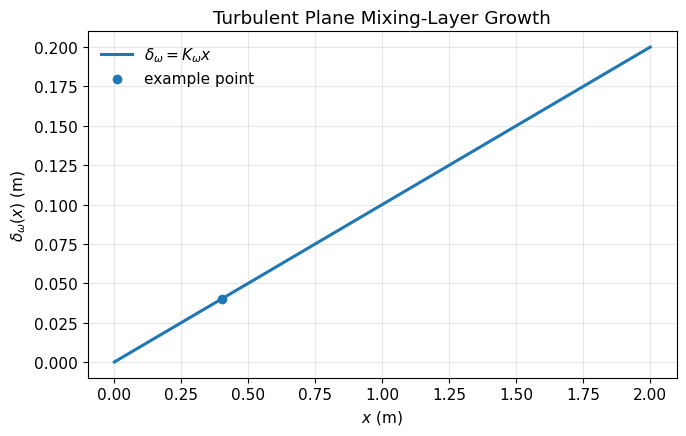

In [3]:

# Plot mixing-layer growth
x = np.linspace(0, 2.0, 300)
delta = K_omega * x

plt.figure()
plt.plot(x, delta, label=r"$\delta_\omega=K_\omega x$")
plt.scatter([x_eval], [delta_omega], zorder=3, label="example point")
plt.xlabel(r"$x$ (m)")
plt.ylabel(r"$\delta_\omega(x)$ (m)")
plt.title("Turbulent Plane Mixing-Layer Growth")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()



### Similarity representation for the mixing layer

A convenient schematic similarity representation is

\[
\frac{U-U_m}{\Delta U} = \frac{1}{2}\tanh(a\eta),
\qquad
\eta = \frac{y}{\delta(x)},
\qquad
U_m=\frac{U_1+U_2}{2}.
\]

A representative Reynolds shear-stress profile is modeled as a localized distribution centered near the mixing-layer center:

\[
\frac{-\overline{u'v'}}{(\Delta U)^2}
= A_R \exp\left[-\left(\frac{\eta}{\sigma_R}\right)^2\right].
\]

These profiles are schematic teaching models for visualizing similarity collapse.


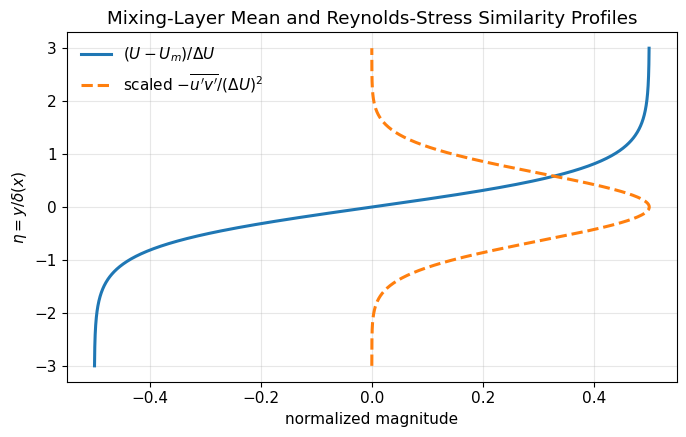

In [4]:

eta = np.linspace(-3.0, 3.0, 500)
a = 1.35
A_R = 0.015
sigma_R = 0.9

U_norm = 0.5 * np.tanh(a * eta)                 # (U - Um)/DeltaU
R_norm = A_R * np.exp(-(eta / sigma_R)**2)      # -u'v'/(DeltaU)^2

plt.figure()
plt.plot(U_norm, eta, label=r"$(U-U_m)/\Delta U$")
plt.plot(R_norm / R_norm.max() * 0.5, eta, linestyle="--",
         label=r"scaled $-\overline{u'v'}/(\Delta U)^2$")
plt.xlabel("normalized magnitude")
plt.ylabel(r"$\eta=y/\delta(x)$")
plt.title("Mixing-Layer Mean and Reynolds-Stress Similarity Profiles")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()



## Example 13.2: Centerline decay and spreading of a turbulent round jet

In the self-similar region of a round jet,

\[
U_c(x) \sim x^{-1},
\qquad
b(x) \sim x.
\]

With \(U_c(0.50\,\mathrm{m})=8.0\,\mathrm{m\,s^{-1}}\), write

\[
U_c(x)=\frac{A}{x}.
\]


In [ ]:

# Given values
x_ref = 0.50      # m
Uc_ref = 8.0      # m/s
alpha_jet = 0.09
x_target = 1.20   # m

A = Uc_ref * x_ref
Uc_target = A / x_target
b_target = alpha_jet * x_target

print(f"A = {A:.2f} m^2/s")
print(f"Uc({x_target:.2f} m) = {Uc_target:.2f} m/s")
print(f"b({x_target:.2f} m) = {b_target:.3f} m")


In [5]:

x = np.linspace(0.3, 2.0, 300)
Uc = A / x
b = alpha_jet * x

plt.figure()
plt.plot(x, Uc, label=r"$U_c=A/x$")
plt.scatter([x_target], [Uc_target], zorder=3)
plt.xlabel(r"$x$ (m)")
plt.ylabel(r"$U_c(x)$ (m/s)")
plt.title("Round Jet Centerline Velocity Decay")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(x, b, label=r"$b=\alpha x$")
plt.scatter([x_target], [b_target], zorder=3)
plt.xlabel(r"$x$ (m)")
plt.ylabel(r"$b(x)$ (m)")
plt.title("Round Jet Linear Spreading")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


NameError: name 'A' is not defined


## Example 13.3: Centerline scales in a pure turbulent plume

For a pure plume, use the similarity scalings

\[
U_c(x)=C_U B^{1/3}x^{-1/3},
\qquad
b(x)=\alpha x,
\qquad
b_c(x)=C_b B^{2/3}x^{-5/3}.
\]

Here \(B\) is the buoyancy flux and \(b_c\) denotes the centerline buoyancy scale.


In [ ]:

# Given values
B = 0.020       # m^4/s^3
C_U = 1.10
C_b = 0.80
alpha_plume = 0.12
x_plume = 2.0  # m

Uc_plume = C_U * B**(1/3) * x_plume**(-1/3)
b_plume = alpha_plume * x_plume
bc_plume = C_b * B**(2/3) * x_plume**(-5/3)

print(f"Uc({x_plume:.1f} m) = {Uc_plume:.3f} m/s")
print(f"b({x_plume:.1f} m) = {b_plume:.3f} m")
print(f"bc({x_plume:.1f} m) = {bc_plume:.3e} m/s^2")


In [6]:

x = np.linspace(0.5, 6.0, 300)
Uc_plume_curve = C_U * B**(1/3) * x**(-1/3)
b_plume_curve = alpha_plume * x
bc_plume_curve = C_b * B**(2/3) * x**(-5/3)

plt.figure()
plt.plot(x, Uc_plume_curve, label=r"$U_c\sim x^{-1/3}$")
plt.scatter([x_plume], [Uc_plume], zorder=3)
plt.xlabel(r"$x$ (m)")
plt.ylabel(r"$U_c(x)$ (m/s)")
plt.title("Pure Plume Centerline Velocity Scaling")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(x, b_plume_curve, label=r"$b=\alpha x$")
plt.scatter([x_plume], [b_plume], zorder=3)
plt.xlabel(r"$x$ (m)")
plt.ylabel(r"$b(x)$ (m)")
plt.title("Pure Plume Linear Width Growth")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(x, bc_plume_curve, label=r"$b_c\sim x^{-5/3}$")
plt.scatter([x_plume], [bc_plume], zorder=3)
plt.xlabel(r"$x$ (m)")
plt.ylabel(r"$b_c(x)$ (m/s$^2$)")
plt.title("Pure Plume Centerline Buoyancy Scaling")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


NameError: name 'C_U' is not defined


## Example 13.4: Turbulent kinetic-energy production in three flows

For shear production,

\[
P = -\overline{u'v'}\frac{\partial U}{\partial n}.
\]

For a plume, buoyancy production may also contribute:

\[
G = \overline{u'b'}.
\]


In [ ]:

minus_uv = 0.80     # m^2/s^2; this represents -u'v'
dUdn = 120.0        # 1/s
G_plume = 0.15      # m^2/s^3

P_shear = minus_uv * dUdn
P_ML = P_shear
P_jet = P_shear
P_plume_shear = P_shear
P_plume_total = P_plume_shear + G_plume

print(f"P_ML = {P_ML:.2f} m^2/s^3")
print(f"P_jet = {P_jet:.2f} m^2/s^3")
print(f"P_plume_shear = {P_plume_shear:.2f} m^2/s^3")
print(f"G_plume = {G_plume:.2f} m^2/s^3")
print(f"P_plume_total = {P_plume_total:.2f} m^2/s^3")


In [ ]:

labels = ["Mixing layer", "Jet", "Plume\n(shear)", "Plume\n(total)"]
values = [P_ML, P_jet, P_plume_shear, P_plume_total]

plt.figure()
plt.bar(labels, values)
plt.ylabel(r"production (m$^2$ s$^{-3}$)")
plt.title("TKE Production Estimates in Canonical Free Shear Flows")
plt.tight_layout()
plt.show()



## Example 13.5: Entrainment and growth of a round jet

For a fully developed round jet,

\[
U_c(x)=\frac{6.0}{x},
\qquad
b(x)\sim \alpha x,
\qquad
v_e\sim \alpha U_c.
\]

The growth of volume flux is estimated as

\[
\frac{dQ}{dx}\sim 2\pi b v_e.
\]


In [ ]:

alpha = 0.08
x_e = 1.0
Uc_e = 6.0 / x_e
b_e = alpha * x_e
v_e = alpha * Uc_e
dQdx = 2 * np.pi * b_e * v_e

print(f"Uc({x_e:.1f} m) = {Uc_e:.2f} m/s")
print(f"b({x_e:.1f} m) = {b_e:.3f} m")
print(f"v_e({x_e:.1f} m) = {v_e:.3f} m/s")
print(f"dQ/dx = {dQdx:.3f} m^2/s")


In [ ]:

x = np.linspace(0.5, 4.0, 300)
Uc = 6.0 / x
b = alpha * x
ve = alpha * Uc
dQdx_curve = 2 * np.pi * b * ve

plt.figure()
plt.plot(x, Uc, label=r"$U_c=6/x$")
plt.plot(x, b, label=r"$b=\alpha x$")
plt.plot(x, ve, label=r"$v_e=\alpha U_c$")
plt.xlabel(r"$x$ (m)")
plt.title("Jet Entrainment Scaling")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(x, dQdx_curve, label=r"$dQ/dx\sim 2\pi b v_e$")
plt.scatter([x_e], [dQdx], zorder=3)
plt.xlabel(r"$x$ (m)")
plt.ylabel(r"$dQ/dx$ (m$^2$/s)")
plt.title("Round Jet Volume-Flux Growth Estimate")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()



## Synthesis: canonical free shear flow scalings

| Flow | Main driving mechanism | Width scaling | Velocity scaling |
|---|---|---|---|
| Plane mixing layer | imposed velocity difference | \(\delta_\omega \sim x\) | \(\Delta U = U_1-U_2\) |
| Round jet | conserved momentum flux | \(b\sim x\) | \(U_c\sim x^{-1}\) |
| Pure plume | conserved buoyancy flux | \(b\sim x\) | \(U_c\sim x^{-1/3}\) |

The common feature is entrainment-driven spreading. The difference lies in the conserved quantity that determines the centerline velocity decay.
